### Forecast Spectral Indices

This notebook demonstrates how to use the `ForecastTS` class to forecast spectral indices using XGBoost. It includes steps for loading the data, preprocessing, training the model, and visualizing the forecasts.


In [1]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

import sys
sys.path.append('/Users/aycha.tammour/geospatial_mlops')

from scripts.process_ts import DataAnalysis
from scripts.forecast_ts import ForecastTS
from scripts.read_bucket import DataReader

In [101]:
# Load the data
# Area of interest
aoi_name = "atamah_camp"

data_reader = DataReader()
ts_data = data_reader.read_ts(aoi_name)
print(f"{aoi_name.replace('_', ' ').title()}: {ts_data.shape}")
ts_data.head(n=2)

Data loaded: (399, 9)
Atamah Camp: (399, 9)


,time,ndvi,bsi,ndmi,nbr,aoi_name,geometry,geometry_wkt,bbox_area
0,2018-03-12 08:29:03.369,0.426711,-0.001167,0.087464,0.221377,atamah_camp,"[2, 4, 0, 0, 0, 0, 0, 0, 236, 146, 18, 66, 138...",POLYGON ((36.732521110322224 36.27396741081821...,0.006417
1,2018-03-12 08:29:51.297,0.434007,0.004068,0.087596,0.222577,atamah_camp,"[2, 4, 0, 0, 0, 0, 0, 0, 236, 146, 18, 66, 138...",POLYGON ((36.732521110322224 36.27396741081821...,0.006417


Let's plot the raw data and see what it looks like.

In [102]:
# define a color palette for the plots
cmap = plt.get_cmap("BrBG")
colors = cmap(np.linspace(0, 1, 12))

In [103]:
raw_data = ts_data.copy()
raw_data.set_index('time', inplace=True)
raw_data.sort_index(inplace=True)

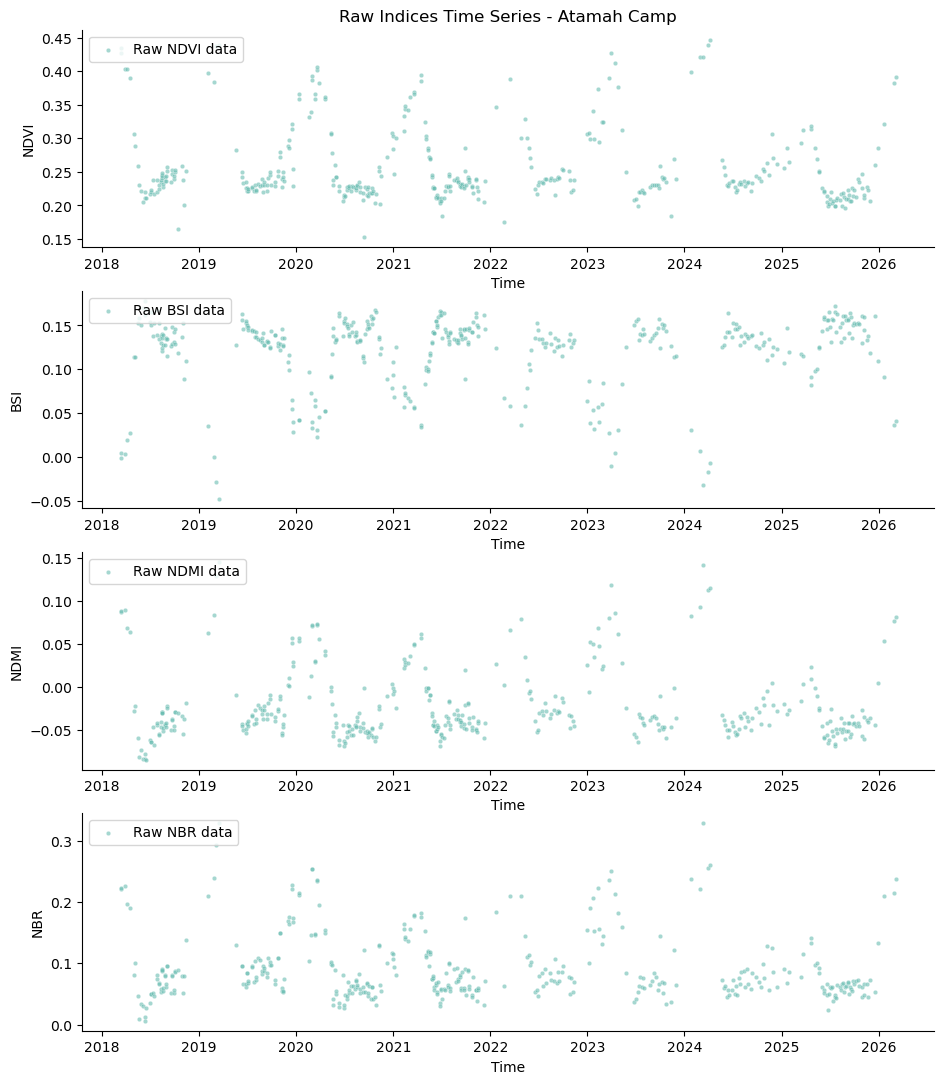

In [104]:
fig, ax = plt.subplots(4, 1, figsize=(11, 13))

sns.scatterplot(x='time', y='ndvi',
            data=raw_data,
            color=colors[8],
            alpha=0.6,
            marker='o',
            s=10,
            label='Raw NDVI data',
            ax=ax[0])

sns.scatterplot(x='time', y='bsi',
            data=raw_data,
            color=colors[8],
            alpha=0.6,
            marker='o',
            s=10,
            label='Raw BSI data',
            ax=ax[1])

sns.scatterplot(x='time', y='ndmi',
            data=raw_data,
            color=colors[8],
            alpha=0.6,
            marker='o',
            s=10,
            label='Raw NDMI data',
            ax=ax[2])

sns.scatterplot(x='time', y='nbr',
            data=raw_data,
            color=colors[8],
            alpha=0.6,
            marker='o',
            s=10,
            label='Raw NBR data',
            ax=ax[3])

sns.despine()

ax[0].set_title(f"Raw Indices Time Series - {aoi_name.replace('_', ' ').title()}")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("NDVI")
ax[0].legend(loc='upper left')

ax[1].set_xlabel("Time")
ax[1].set_ylabel("BSI")
ax[1].legend(loc='upper left')

ax[2].set_xlabel("Time")
ax[2].set_ylabel("NDMI")
ax[2].legend(loc='upper left')

ax[3].set_xlabel("Time")
ax[3].set_ylabel("NBR")
ax[3].legend(loc='upper left')

The data shows a clear seasonal pattern, with peaks and troughs corresponding to the growing season. We can also see some noise in the data, which is not uncommon in this type of data. Another important thing to note is that the spacing of the data points is not regular. This requires some work on preprocessing the data before it is fed into the forecasting model.

In [105]:
# Perform preprocessing: resmpling, interpolation, and smoothing

da = DataAnalysis()
spec_indices = ['ndvi', 'bsi', 'ndmi', 'nbr']

proc_ts = da.preprocess_time_series(spec_indices, ts_data)
print(proc_ts.shape)
proc_ts.head(n=2)

(417, 4)


,ndvi_smooth,bsi_smooth,ndmi_smooth,nbr_smooth
time,,,,
2018-03-18,0.430359,0.001450,0.087530,0.221977
2018-03-25,0.423546,0.002039,0.088046,0.222902


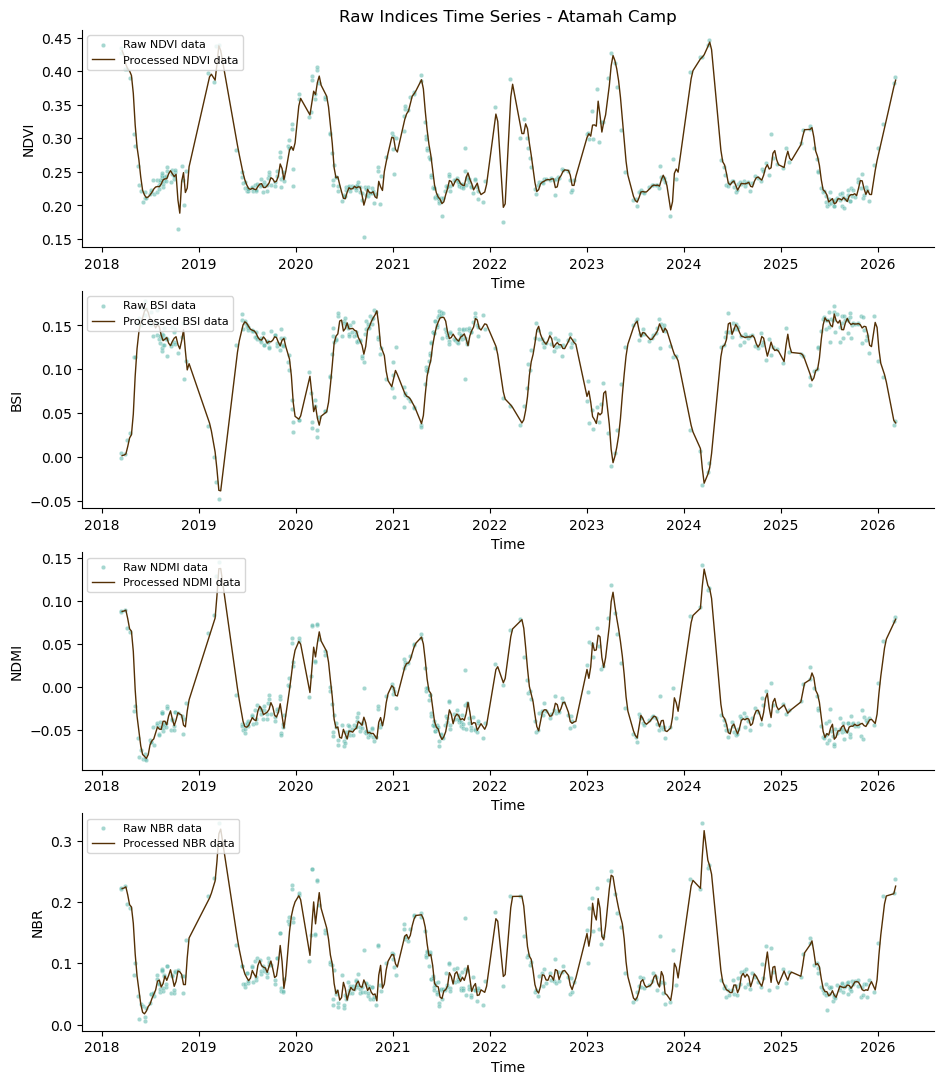

In [106]:
fig, ax = plt.subplots(4, 1, figsize=(11, 13))

sns.scatterplot(x='time', y='ndvi',
            data=raw_data,
            color=colors[8],
            alpha=0.6,
            marker='o',
            s=10,
            label='Raw NDVI data',
            ax=ax[0])

sns.lineplot(x='time', y='ndvi_smooth',
            data=proc_ts,
            lw=1,
            color=colors[0],
            label='Processed NDVI data',
            ax=ax[0])

sns.scatterplot(x='time', y='bsi',
            data=raw_data,
            color=colors[8],
            alpha=0.6,
            marker='o',
            s=10,
            label='Raw BSI data',
            ax=ax[1])

sns.lineplot(x='time', y='bsi_smooth',
            data=proc_ts,
            lw=1,
            color=colors[0],
            label='Processed BSI data',
            ax=ax[1])

sns.scatterplot(x='time', y='ndmi',
            data=raw_data,
            color=colors[8],
            alpha=0.6,
            marker='o',
            s=10,
            label='Raw NDMI data',
            ax=ax[2])

sns.lineplot(x='time', y='ndmi_smooth',
            data=proc_ts,
            lw=1,
            color=colors[0],
            label='Processed NDMI data',
            ax=ax[2])

sns.scatterplot(x='time', y='nbr',
            data=raw_data,
            color=colors[8],
            alpha=0.6,
            marker='o',
            s=10,
            label='Raw NBR data',
            ax=ax[3])

sns.lineplot(x='time', y='nbr_smooth',
            data=proc_ts,
            lw=1,
            color=colors[0],
            label='Processed NBR data',
            ax=ax[3])

sns.despine()

ax[0].set_title(f"Raw Indices Time Series - {aoi_name.replace('_', ' ').title()}")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("NDVI")
ax[0].legend(loc='upper left', fontsize=8)

ax[1].set_xlabel("Time")
ax[1].set_ylabel("BSI")
ax[1].legend(loc='upper left', fontsize=8)

ax[2].set_xlabel("Time")
ax[2].set_ylabel("NDMI")
ax[2].legend(loc='upper left', fontsize=8)

ax[3].set_xlabel("Time")
ax[3].set_ylabel("NBR")
ax[3].legend(loc='upper left', fontsize=8)

Now, the data is ready to be fed into the forecasting model. We will use the `ForecastTS` class to train an XGBoost model on the data and make forecasts for the next 8 weeks. 

The `ForecastTS` class performs hyperparameter tuning using `Optuna` and cross-validation to find the best parameters for the XGBoost model. This is important for many reasons, including avoiding overfitting (the model memorizes the training data instead of learning general patterns) and improving the model's performance on unseen data. After training the model, we will visualize the forecasts and compare them to the actual data to see how well the model is performing.

The `ForecastTS` class also includes functionality for logging the model and its parameters to `MLflow`, which is a great tool for tracking machine learning experiments and models. This allows us to keep track of different runs, compare models, and easily deploy the best model in production.

In [107]:
# instantiate the forecasting class. The aoi_name is used for logging the model and its parameters in MLflow.
forecast_ts = ForecastTS(aoi_name=aoi_name)

In this step we format the input data in the format required by the forecasting model. The `unique_id` column is used to identify the time series (NDVI, BSI, etc.), and the `ds` column is used to identify the time column

In [108]:
input_df = forecast_ts.format_input_data(proc_ts)
input_df.head()

,ds,y,unique_id
0,2018-03-18,0.430359,ndvi
1,2018-03-25,0.426953,ndvi
2,2018-04-01,0.416734,ndvi
3,2018-04-08,0.406630,ndvi
4,2018-04-15,0.401792,ndvi


Now, we split the available data into a training set and a test set. The training set is used to train the model, while the test set is used to evaluate the model's performance on unseen data. We will use the last 12 weeks of data as the test set, and the rest of the data as the training set.

In [109]:
h= 12 # forecast horizon (number of weeks to forecast)

# make sure the data is sorted by date for each unique_id (i.e., each spectral index.)
input_df.sort_values(by=['unique_id', 'ds'], inplace=True)

train_dfs = []
test_dfs = []
for i in list(input_df['unique_id'].unique()):
    temp_train = input_df[input_df['unique_id'] == i].iloc[:-h]
    temp_test = input_df[input_df['unique_id'] == i].iloc[-h:]
    print(f"Unique ID {i} - Train shape: {temp_train.shape}, Test shape: {temp_test.shape}")

    train_dfs.append(temp_train)
    test_dfs.append(temp_test)

train_df = pd.concat(train_dfs)
test_df = pd.concat(test_dfs)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Unique ID bsi - Train shape: (405, 3), Test shape: (12, 3)
Unique ID nbr - Train shape: (405, 3), Test shape: (12, 3)
Unique ID ndmi - Train shape: (405, 3), Test shape: (12, 3)
Unique ID ndvi - Train shape: (405, 3), Test shape: (12, 3)
Train shape: (1620, 3)
Test shape: (48, 3)


Now train the model and keep only the best fit. The model will be save so it can be used later for inference. The best model is determined based on the mean absolute error (MAE) on the cross-validation sets. The model with the lowest MAE is selected as the best model.

In [110]:
preds = forecast_ts.forecast_xgb(input_df, h)

  0%|          | 0/100 [00:00<?, ?it/s]

🏃 View run mysterious-whale-194 at: http://127.0.0.1:5000/#/experiments/41/runs/c9e20baa28884744b1b8e895b32cbbf6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/41
🏃 View run lyrical-robin-237 at: http://127.0.0.1:5000/#/experiments/41/runs/ef1215652a794512861d0f2be4279b42
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/41
🏃 View run omniscient-zebra-689 at: http://127.0.0.1:5000/#/experiments/41/runs/6570a7248a7e402ebf931acd65f235bf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/41
🏃 View run learned-bear-930 at: http://127.0.0.1:5000/#/experiments/41/runs/6f7e4308c6844b0391f95647c7ae1df6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/41
🏃 View run unequaled-steed-238 at: http://127.0.0.1:5000/#/experiments/41/runs/52b5b2f3dacf4bebbe17678c6bd6c49e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/41
🏃 View run righteous-sheep-445 at: http://127.0.0.1:5000/#/experiments/41/runs/296a5622821d4a43b4e00fafb3a3a89d
🧪 View experiment at: http

In [111]:
h = 12
preds_from_model = forecast_ts.predict_xgb(experiment_name='atamah_camp_2026-04-09_20-46', 
                                           forecast_horizon=h,
                                           time_stamp='2026-04-09_19-07')

1. searching runs...
2. found run: fa621fc74cb64dca89d6d50645c1411c
Loading model from run: fa621fc74cb64dca89d6d50645c1411c
mlflow-artifacts:/41/fa621fc74cb64dca89d6d50645c1411c/artifacts
4. loading pickle from: ./forecasting_models/mf_best_atamah_camp_2026-04-09_20-46.pkl
5. loading pickle...
6. pickle loaded
7. predicting...
8. done
Forecast saved to: s3://spectral-indices-monitoring/forecasts/atamah_camp_2026-04-09_20-46/xgb_forecast_atamah_camp_2026-04-09.parquet


In [113]:
import pandas as pd
import plotly.graph_objects as go

# ---------------------------------------------------------------
# REPLACE WITH YOUR DATA
# final_df: your historical dataframe with columns ds, y, unique_id
# forecast: your forecast dataframe with columns ds, XGBRegressor, unique_id
# ---------------------------------------------------------------

final_df = input_df.copy()
forecast = preds_from_model.copy()
series_ids    = sorted(final_df["unique_id"].unique())
spec_indices  = ['ndvi', 'bsi', 'ndmi', 'nbr']
series_labels = [s.upper() for s in spec_indices]  # ['NDVI', 'BSI', 'NDMI', 'NBR']

series_ids = sorted(final_df["unique_id"].unique())
colors     = ["#685A22", "#D85A30", "#2C968F", "#D4537E"]
n          = len(series_ids)

fig = go.Figure()

# Add 3 traces per series: train, test, forecast
for i, sid in enumerate(series_ids):
    color   = colors[i % len(colors)]
    visible = (i == 0)

    h           = final_df[final_df["unique_id"] == sid].sort_values("ds")
    f           = forecast[forecast["unique_id"] == sid].sort_values("ds")
    fcast_start = f["ds"].min()

    train = h[h["ds"] <  fcast_start]
    test  = h[h["ds"] >= fcast_start]

    fig.add_trace(go.Scatter(
        x=train["ds"], y=train["y"],
        mode="lines", name="Train",
        line=dict(color=color, width=2),
        visible=visible,
        hovertemplate="<b>%{x}</b><br>%{y:.2f}<extra>Train</extra>"
    ))

    fig.add_trace(go.Scatter(
        x=test["ds"], y=test["y"],
        mode="lines", name="Test",
        line=dict(color=color, width=3),
        opacity=0.4,
        visible=visible,
        hovertemplate="<b>%{x}</b><br>%{y:.2f}<extra>Test</extra>"
    ))

    fig.add_trace(go.Scatter(
        x=f["ds"], y=f["XGBRegressor"],
        mode="lines", name="Forecast",
        line=dict(color=color, width=2, dash="dot"),
        visible=visible,
        hovertemplate="<b>%{x}</b><br>%{y:.2f}<extra>Forecast</extra>"
    ))

# Build dropdown buttons — 3 traces per series
buttons = []
for i, sid in enumerate(series_ids):
    visible = [False] * (n * 3)
    visible[i * 3]     = True  # train
    visible[i * 3 + 1] = True  # test
    visible[i * 3 + 2] = True  # forecast

    f           = forecast[forecast["unique_id"] == sid].sort_values("ds")
    fcast_start = f["ds"].min().strftime("%Y-%m-%d")

    buttons.append(dict(
        label=series_labels[i],
        method="update",
        args=[
            {"visible": visible},
            {
                "shapes": [dict(
                    type="line", x0=fcast_start, x1=fcast_start,
                    y0=0, y1=1, yref="paper",
                    line=dict(color="#ccc", width=1, dash="dash")
                )],
                "annotations": [dict(
                    x=fcast_start, y=0.98, yref="paper",
                    xanchor="left", yanchor="top",
                    text="forecast start", showarrow=False,
                    font=dict(size=10, color="#aaa")
                )]
            }
        ]
    ))

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        x=0, xanchor="left",
        y=1.12, yanchor="top",
        showactive=True,
        bgcolor="white",
        bordercolor="#ccc",
        font=dict(size=13)
    )],
    hovermode="x unified",
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=80, r=20, b=60, l=60),
    xaxis=dict(showgrid=True, gridcolor="#ebebeb", showline=True, linecolor="#d0d0cc"),
    yaxis=dict(showgrid=True, gridcolor="#ebebeb", showline=True, linecolor="#d0d0cc"),
    legend=dict(orientation="h", x=0, y=-0.15, font=dict(size=12), bgcolor="rgba(0,0,0,0)"),
)

fig.show()
fig.write_html("atamah_camp_forecast_chart.html", include_plotlyjs="cdn")
print("Saved to atamah_camp_forecast_chart.html")

Saved to atamah_camp_forecast_chart.html
